<a href="https://colab.research.google.com/github/Rochdy-max/insurance_review_nlp/blob/main/notebooks/insurance_review_nlp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. Fix the dependency error for IPython
!pip install -q jedi

# 2. Install core libraries
!pip install -q pandas spacy openpyxl streamlit

# Install pandarallel
!pip install -q pandarallel

# 3. Install the CORRECT spellchecker package
# Note: the library is 'pyspellchecker', even if you import 'spellchecker'
!pip install -q pyspellchecker

!pip install -qU transformers # torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 61.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 29.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 111.8 MB/s eta 0:00:00


In [ ]:
# 4. Download the English model (since our files are translated)
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 18.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import os
import pandas as pd
import glob
import zipfile

import spacy
import re
from spellchecker import SpellChecker
from pandarallel import pandarallel
import multiprocessing

In [ ]:
ROOT_DIR = os.getcwd()
# ROOT_DIR = ".." # Based on repository architecture

%cd "{ROOT_DIR}"

In [ ]:
extracted_file = "data/Traduction avis clients/"

if os.path.exists(extracted_file):
    print(f"Le fichier {extracted_file} existe déjà.")
else:
    with zipfile.ZipFile('data/Traduction avis clients.zip', 'r') as zip_ref:
        zip_ref.extractall("data/")

In [ ]:
# 1. Lister tous les fichiers XLSX dans le dossier par défaut de Colab
all_files = glob.glob("data/Traduction avis clients/*.xlsx")

# 2. Fusionner
li = []
for filename in all_files:
    df_temp = pd.read_excel(filename)  # Changed from pd.read_csv to pd.read_excel
    li.append(df_temp)

df = pd.concat(li, axis=0, ignore_index=True)
print(f"Total lignes : {len(df)}")

Total lignes : 34435


In [ ]:
print(len(df.columns))
df.columns

11


Index(['note', 'auteur', 'avis', 'assureur', 'produit', 'type',
       'date_publication', 'date_exp', 'avis_en', 'avis_cor', 'avis_cor_en'],
      dtype='object')

In [ ]:
df.head()

,note,auteur,avis,assureur,produit,type,date_publication,date_exp,avis_en,avis_cor,avis_cor_en
0,1.0,alix-71285,L'olivier Assurances vous fait un devis et vou...,L'olivier Assurance,auto,train,14/02/2019,01/02/2019,The Olivier Assurances gives you a quote and a...,NaN,NaN
1,1.0,mimi-53221,axa a des gros gros soucis avec leur site!!!!!...,AXA,vie,train,13/03/2017,01/03/2017,Axa has big big concerns with their site !!!!!...,NaN,NaN
2,4.0,chaise-129429,Je suis satisfait du service \nle prix est int...,L'olivier Assurance,auto,train,25/08/2021,01/08/2021,I am satisfied with the service\nThe price is ...,NaN,NaN
3,1.0,kit-124951,Inscription pénible... Ils perdent les documen...,Mercer,sante,train,27/07/2021,01/07/2021,Painful registration ... They lose the documen...,NaN,NaN
4,2.0,gogotte-78139,aucune reponse a ce jour apres 1 mois pour une...,Direct Assurance,habitation,train,02/08/2019,01/08/2019,No response to this day after 1 month for a re...,NaN,NaN


In [ ]:
# 1. On regarde combien de lignes ont des valeurs manquantes
print("Valeurs manquantes avant filtrage :")
print(df[['avis_en', 'note']].isnull().sum())

# 2. On supprime les lignes où l'avis est vide OU la note est absente
# subset=['avis_en', 'note'] cible uniquement ces deux colonnes cruciales
df.dropna(subset=['avis_en', 'note'], inplace=True)

# 3. On supprime les avis qui seraient juste des espaces ou des textes trop courts
df = df[df['avis_en'].str.len() > 2]

# 4. On réinitialise l'index
df.reset_index(drop=True, inplace=True)

print(f"\nNettoyage terminé. Il reste {len(df)} lignes prêtes à être traitées.")

Valeurs manquantes avant filtrage :
avis_en        2
note       10331
dtype: int64

Nettoyage terminé. Il reste 24103 lignes prêtes à être traitées.


Spell Checking and Lemmatization

In [ ]:
# On charge les outils
spell = SpellChecker(language='en')
nlp = spacy.load('en_core_web_sm', disable=['ner', 'parser'])

# Fonction optimisée avec "Cache" pour ne pas corriger deux fois le même mot
cache = {}

In [ ]:
def clean_parallel(text):
    if not isinstance(text, str) or text.strip() == "": return ""

    text = text.lower()
    text = re.sub(r'[^a-z ]', ' ', text)

    # Correction orthographique ultra-rapide via cache
    words = text.split()
    corrected = []
    for w in words:
        if w not in cache:
            if w in spell.unknown([w]):
                sugg = spell.correction(w)
                cache[w] = sugg if sugg is not None else w
            else:
                cache[w] = w
        corrected.append(cache[w])

    # Lemmatisation SpaCy
    doc = nlp(" ".join(corrected))
    return " ".join([t.lemma_ for t in doc if not t.is_stop and len(t.text) > 2])

In [ ]:
# On active la puissance Multi-coeurs
nb_workers = multiprocessing.cpu_count()
print(f"Puissance disponible : {nb_workers} coeurs CPU")
pandarallel.initialize(progress_bar=True, nb_workers=nb_workers)

Puissance disponible : 2 coeurs CPU
INFO: Pandarallel will run on 2 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


In [ ]:
# L'exécution qui utilise toute la puce
df['text_cleaned'] = df['avis_en'].parallel_apply(clean_parallel)

In [ ]:
os.makedirs("data", exist_ok=True)

In [ ]:
df.to_csv('data/avis_complets_corrige.csv', index=False)

In [ ]:
df = pd.read_csv('data/avis_complets_corrige.csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24103 entries, 0 to 24102
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   note              24103 non-null  float64
 1   auteur            24102 non-null  object 
 2   avis              24103 non-null  object 
 3   assureur          24103 non-null  object 
 4   produit           24103 non-null  object 
 5   type              24103 non-null  object 
 6   date_publication  24103 non-null  object 
 7   date_exp          24103 non-null  object 
 8   avis_en           24103 non-null  object 
 9   avis_cor          0 non-null      float64
 10  avis_cor_en       0 non-null      float64
 11  text_cleaned      24092 non-null  object 
dtypes: float64(3), object(9)
memory usage: 2.2+ MB


In [ ]:
df[df["text_cleaned"].isna()]["avis_en"]

,avis_en
1998,RAS .............................................
7481,For Nadège
8233,"I will have it, I will have it, that they say...."
8368,Ras
9304,See the least
11247,See below
13049,Nadège
15035,Nothing to say
22872,Null
23478,Ras


Some reviews have been lost.

But the amount is too low. And none of them really contain some meaningful information. We can do without it.

In [ ]:
df.dropna(subset=["text_cleaned"], inplace=True)
df.reset_index(drop=True, inplace=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24092 entries, 0 to 24091
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   note              24092 non-null  float64
 1   auteur            24091 non-null  object 
 2   avis              24092 non-null  object 
 3   assureur          24092 non-null  object 
 4   produit           24092 non-null  object 
 5   type              24092 non-null  object 
 6   date_publication  24092 non-null  object 
 7   date_exp          24092 non-null  object 
 8   avis_en           24092 non-null  object 
 9   avis_cor          0 non-null      float64
 10  avis_cor_en       0 non-null      float64
 11  text_cleaned      24092 non-null  object 
dtypes: float64(3), object(9)
memory usage: 2.2+ MB


Distribution Plot

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

/tmp/ipykernel_11680/592913329.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='note', data=df, palette='viridis')


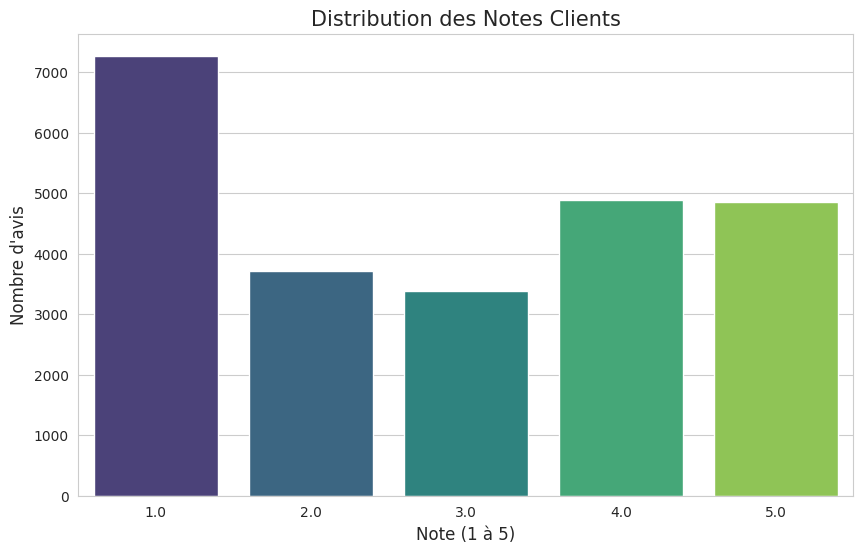

In [ ]:
# Visualisation de la répartition des notes
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
sns.countplot(x='note', data=df, palette='viridis')

plt.title('Distribution des Notes Clients', fontsize=15)
plt.xlabel('Note (1 à 5)', fontsize=12)
plt.ylabel("Nombre d'avis", fontsize=12)
plt.show()

In [ ]:
print("Comptage par note :")
print(df['note'].value_counts())

Comptage par note :
note
1.0    7271
4.0    4885
5.0    4849
2.0    3716
3.0    3382
Name: count, dtype: int64


Word frequency

In [ ]:
from collections import Counter

In [ ]:
# 1. On rassemble tous les mots nettoyés
all_words = (" ".join(df['text_cleaned'].astype(str))).split()

# 2. On compte les fréquences
word_freq = Counter(all_words)
common_words = word_freq.most_common(20)

/tmp/ipykernel_11680/242981599.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(words), palette='magma')


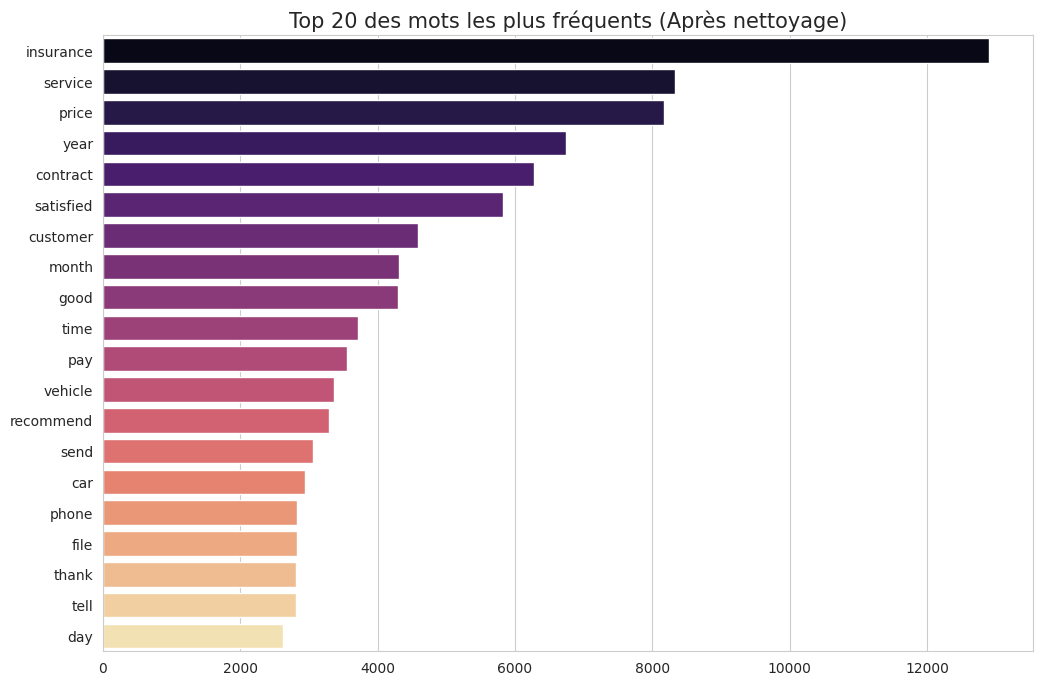

In [ ]:
# 3. Création du graphique
words, counts = zip(*common_words)
plt.figure(figsize=(12, 8))
sns.barplot(x=list(counts), y=list(words), palette='magma')
plt.title('Top 20 des mots les plus fréquents (Après nettoyage)', fontsize=15)
plt.show()

Word Cloud

In [ ]:
from wordcloud import WordCloud

In [ ]:
# On génère le nuage à partir de la colonne nettoyée
full_text = " ".join(df['text_cleaned'].astype(str))

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    colormap='plasma'
).generate(full_text)

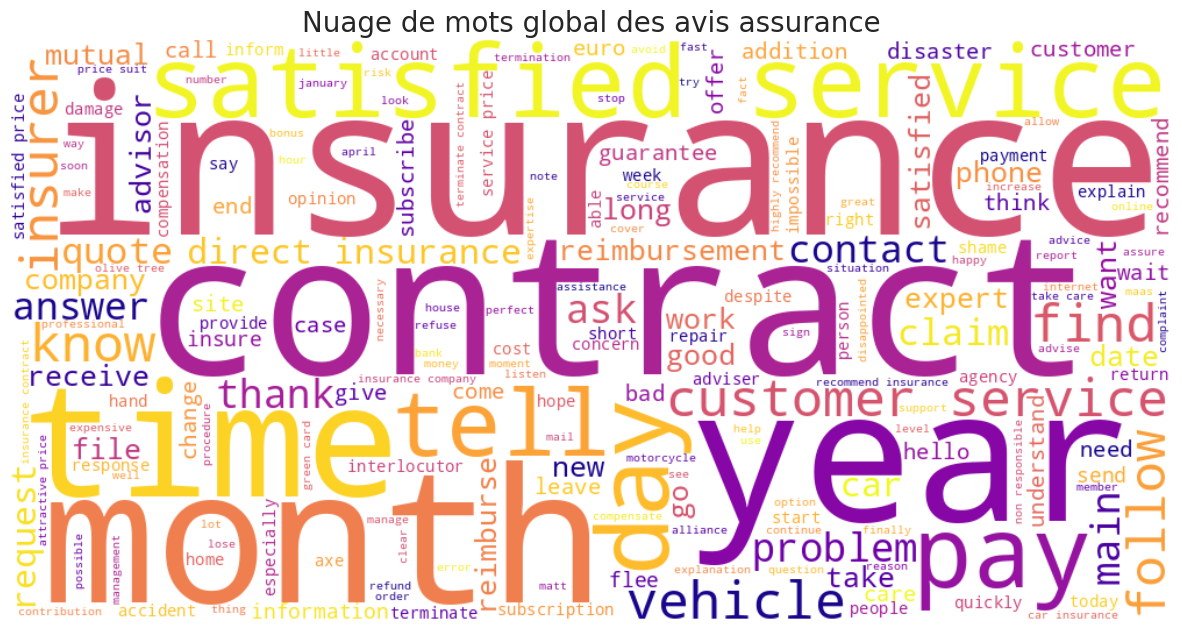

In [ ]:
plt.figure(figsize=(15, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Nuage de mots global des avis assurance', fontsize=20)
plt.show()

# Mark Prediction

In [ ]:
from transformers import pipeline
from tqdm import tqdm
import torch
import gc
import numpy as np

In [ ]:
# On active le GPU s'il est disponible
device = 0 if torch.cuda.is_available() else -1

In [ ]:
def clean_cache():
    gc.collect()
    torch.cuda.empty_cache()

clean_cache()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from imblearn.over_sampling import RandomOverSampler

In [ ]:
X = (
    df[['avis_en', 'text_cleaned']]
    .astype(str)
)
y = df['note'].values

# Split Train/Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
Counter(y_train)

Counter({np.float64(5.0): 3879,
         np.float64(2.0): 2973,
         np.float64(1.0): 5815,
         np.float64(4.0): 3905,
         np.float64(3.0): 2701})

In [ ]:
ros = RandomOverSampler(random_state=0)

X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)

X_train_ros = X_train_ros["text_cleaned"].to_list()
X_test = X_test["text_cleaned"].to_list()

In [ ]:
Counter(y_train_ros)

Counter({np.float64(5.0): 5815,
         np.float64(2.0): 5815,
         np.float64(1.0): 5815,
         np.float64(4.0): 5815,
         np.float64(3.0): 5815})

In [ ]:
mark_classes = [1, 2, 3, 4, 5]

## Tf-IDF Vectorization Strategy

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import joblib

In [ ]:
# Création de la Pipeline
# 2 étapes: Transforme le texte en vecteurs, puis classifie
tf_idf_clf_mark = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=2000, stop_words='english')),
    ('clf', LogisticRegression())
])

# Entraînement
tf_idf_clf_mark.fit(X_train_ros, y_train_ros)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=2000, stop_words='english')),
                ('clf', LogisticRegression())])

In [ ]:
# Évaluation
tf_idf_pred_mark = tf_idf_clf_mark.predict(X_test)

print("\nRésultats du classifieur :")
print(classification_report(y_test, tf_idf_pred_mark))


Résultats du classifieur :
              precision    recall  f1-score   support

         1.0       0.64      0.57      0.60      1454
         2.0       0.31      0.38      0.34       743
         3.0       0.24      0.29      0.26       676
         4.0       0.43      0.37      0.40       976
         5.0       0.55      0.55      0.55       970

    accuracy                           0.46      4819
   macro avg       0.43      0.43      0.43      4819
weighted avg       0.47      0.46      0.46      4819



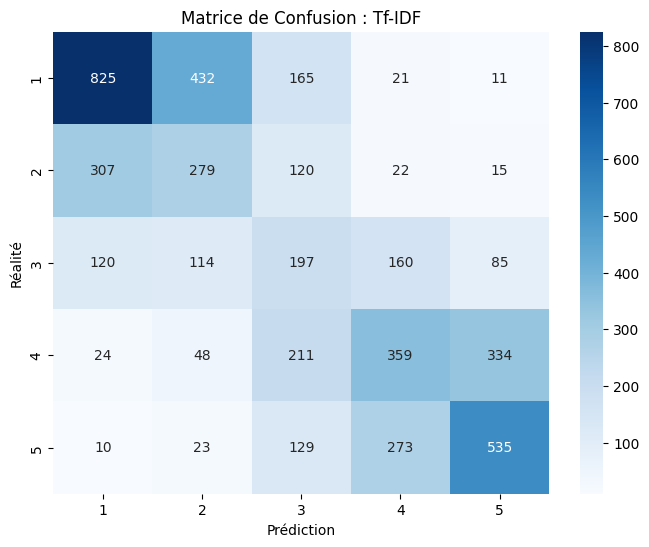

In [ ]:
cm = confusion_matrix(y_test, tf_idf_pred_mark)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=mark_classes, yticklabels=mark_classes
)
plt.title('Matrice de Confusion : Tf-IDF')
plt.ylabel('Réalité')
plt.xlabel('Prédiction')
plt.show()

In [ ]:
os.makedirs('models', exist_ok=True)

In [ ]:
# Sauvegarde du modèle pour l'utiliser dans Streamlit
joblib.dump(tf_idf_clf_mark, 'models/tf_idf_clf_mark.pkl')

['models/tf_idf_nlp.pkl']

## BERT Sentiment Analysis (star-based) Strategy

In [ ]:
# Chargement du modèle BERT (cela peut prendre 1-2 min la première fois)
# Ce modèle prédit de 1 à 5 étoiles directement à partir du texte
bert_sentiment_ppl = pipeline("sentiment-analysis", model="nlptown/bert-base-multilingual-uncased-sentiment")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [ ]:
def get_bert_note(label):
    return int(label.split()[0])

In [ ]:
run_batch_size = 32
bert_test_pred = bert_sentiment_ppl(X_test, batch_size=run_batch_size)

bert_pred_mark = [get_bert_note(res["label"]) for res in bert_test_pred]

print("\nRésultats du classifieur :")
print(classification_report(y_test, bert_pred_mark))


Résultats du classifieur :
              precision    recall  f1-score   support

         1.0       0.55      0.86      0.67      1454
         2.0       0.27      0.03      0.05       743
         3.0       0.25      0.10      0.14       676
         4.0       0.40      0.55      0.46       976
         5.0       0.44      0.39      0.41       970

    accuracy                           0.47      4819
   macro avg       0.38      0.39      0.35      4819
weighted avg       0.41      0.47      0.41      4819



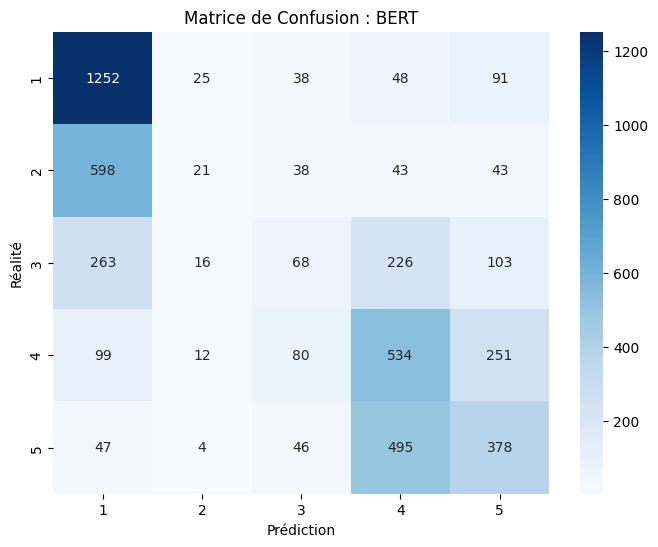

In [ ]:
cm = confusion_matrix(y_test, bert_pred_mark)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=mark_classes, yticklabels=mark_classes
)
plt.title('Matrice de Confusion : BERT')
plt.ylabel('Réalité')
plt.xlabel('Prédiction')
plt.show()

## Features Extraction (Embediding) Strategy

In [ ]:
from transformers import AutoTokenizer, AutoModel
import torch.nn.functional as F
from umap import UMAP

In [ ]:
def extract_cls_features(text_list, tokenizer, model, batch_size=16):
    model.eval()
    all_embeddings = []

    with torch.no_grad():
        for i in tqdm(range(0, len(text_list), batch_size)):
            batch = text_list[i:i+batch_size]
            # Tokenization (on limite à 1024 pour aller plus vite, ou 8192 pour le max)
            inputs = tokenizer(
                batch,
                padding=True,
                truncation=True,
                # max_length=1024,
                return_tensors="pt"
            ).to(device)

            # Passage dans le modèle
            outputs = model(**inputs)

            # On récupère l'embedding du token [CLS] (représentation globale de la phrase)
            embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            all_embeddings.append(embeddings)

    return np.vstack(all_embeddings)

LLM : Microsoft/Deberta

In [ ]:
# 1. Chargement du modèle et du tokenizer
deberta_model_name = "microsoft/deberta-v3-base"

deberta_tokenizer = AutoTokenizer.from_pretrained(deberta_model_name)
deberta_model = AutoModel.from_pretrained(deberta_model_name).to("cuda") # Utilisation du GPU

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/371M [00:00<?, ?B/s]

In [ ]:
# Test sur un échantillon (ou sur tout le df si tu as le temps)
print("Extraction des caractéristiques en cours...")

print("[Training]")
deberta_X_train_features = extract_cls_features(X_train_ros, deberta_tokenizer, deberta_model)

print("[Test]")
deberta_X_test_features = extract_cls_features(X_test, deberta_tokenizer, deberta_model)

Extraction des caractéristiques en cours...
[Training]


100%|██████████| 1818/1818 [02:09<00:00, 14.08it/s]


[Test]


100%|██████████| 302/302 [00:22<00:00, 13.20it/s]


In [ ]:
deberta_X_train_features.shape

(29075, 768)

In [ ]:
deberta_X_test_features.shape

(4819, 768)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


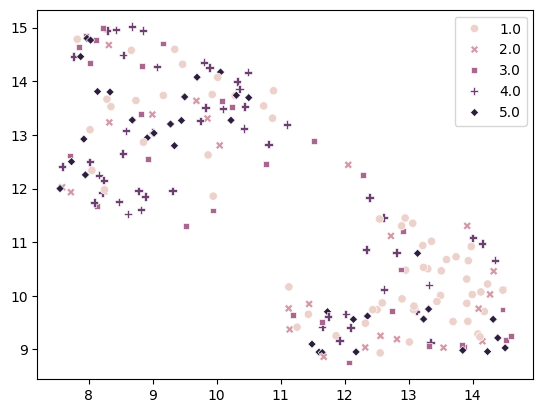

In [ ]:
# deberta_dim_reducer = TSNE(n_components=2, perplexity=50, random_state=42)
deberta_dim_reducer = UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
reduced_features = deberta_dim_reducer.fit_transform(deberta_X_train_features[:200])

sns.scatterplot(
    x=reduced_features[:,0],
    y=reduced_features[:,1],
    hue=y_train_ros[:200],
    style=y_train_ros[:200],
)
plt.show()

During dimensionality reduction, UMAP keeps the global structure of data.

Provided this map, we can deduce that embeddings aren't a lot informative about the mark.

It may require some fine-tuning to produce more fitted results. But let's just stop here and evaluate a classifier model built on those features.

In [ ]:
fe_clf_mark = Pipeline([
    ('scaler', StandardScaler()),
    # ('rf', RandomForestClassifier(n_estimators=100, n_jobs=-1)) # Too long to train
    ('lr', LogisticRegression())
])

print("Entraînement du classifieur Sklearn...")
fe_clf_mark.fit(deberta_X_train_features, y_train_ros)

Entraînement du classifieur Sklearn...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Pipeline(steps=[('scaler', StandardScaler()), ('lr', LogisticRegression())])

In [ ]:
# 3. Évaluation
fe_clf_pred_mark = fe_clf_mark.predict(deberta_X_test_features)

print("\nRésultats du classifieur :")
print(classification_report(y_test, fe_clf_pred_mark))


Résultats du classifieur :
              precision    recall  f1-score   support

         1.0       0.53      0.42      0.47      1454
         2.0       0.25      0.36      0.29       743
         3.0       0.17      0.17      0.17       676
         4.0       0.30      0.29      0.30       976
         5.0       0.39      0.40      0.40       970

    accuracy                           0.35      4819
   macro avg       0.33      0.33      0.32      4819
weighted avg       0.36      0.35      0.35      4819



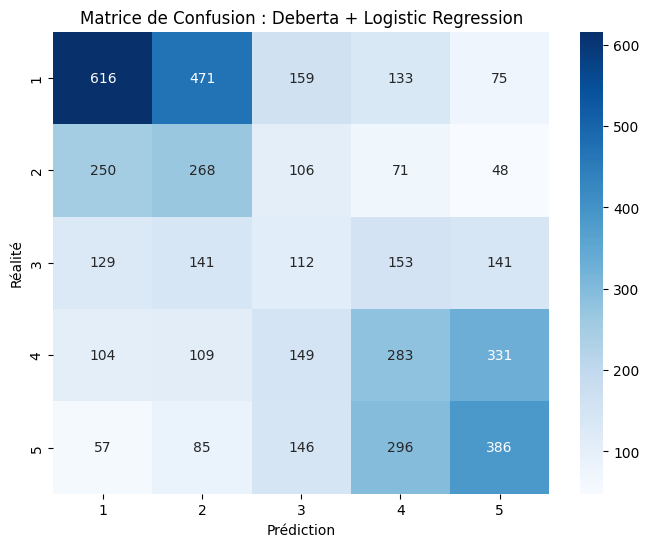

In [ ]:
cm = confusion_matrix(y_test, fe_clf_pred_mark)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=mark_classes, yticklabels=mark_classes
)
plt.title('Matrice de Confusion : Deberta + Logistic Regression')
plt.ylabel('Réalité')
plt.xlabel('Prédiction')
plt.show()

As suggested, we can observe that the model doesn't perform so well.

Let's choose with the Tf-IDF vectorizer for this task. It's not really far from BERT in terms of performance but provides a more lightweight solution.

In [ ]:
# from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
# from datasets import Dataset

In [ ]:
# class SentimentFinetuner:
#     def __init__(self, model_name, num_labels=5, device=0):
#         self.model_name = model_name
#         self.num_labels = num_labels
#         self.device = device

#         # Chargement du tokenizer et du modèle
#         self.tokenizer = AutoTokenizer.from_pretrained(model_name)
#         self.model = AutoModelForSequenceClassification.from_pretrained(
#             model_name,
#             num_labels=num_labels
#         ).to(self.device)

#     def prepare_data(self, texts, labels):
#         # Conversion en format Dataset Hugging Face
#         # On ajuste les labels de [1,5] vers [0,4] pour PyTorch
#         labels = [int(l) for l in labels]

#         data = {"text": texts, "label": labels}
#         dataset = Dataset.from_dict(data)

#         def tokenize_func(examples):
#             return self.tokenizer(
#                 examples["text"],
#                 padding="max_length",
#                 truncation=True,
#                 max_length=128 # Optionnel: limite la mémoire
#             )

#         # On s'assure que la colonne 'label' est bien au format 'int64' (LongTensor)
#         tokenized_ds = dataset.map(tokenize_func, batched=True)
#         tokenized_ds = tokenized_ds.with_format("torch")
#         return tokenized_ds

#     def train(self, train_texts, train_labels, output_dir="./results", epochs=3):
#         train_dataset = self.prepare_data(train_texts, train_labels)

#         training_args = TrainingArguments(
#             output_dir=output_dir,
#             num_train_epochs=epochs,
#             per_device_train_batch_size=8,
#             # evaluation_strategy="no",
#             save_strategy="epoch",
#             learning_rate=2e-5,
#             weight_decay=0.01,
#             logging_steps=10,
#             push_to_hub=False,
#             report_to="none"
#         )

#         self.trainer = Trainer(
#             model=self.model,
#             args=training_args,
#             train_dataset=train_dataset,
#         )

#         return self.trainer.train()

#     def predict(self, texts):
#         # Tokenisation des nouveaux textes
#         inputs = self.tokenizer(
#             texts,
#             padding=True,
#             truncation=True,
#             return_tensors="pt"
#         ).to(self.model.device)

#         with torch.no_grad():
#             outputs = self.model(**inputs)
#             # On récupère l'index de la classe avec la plus haute probabilité
#             predictions = torch.argmax(outputs.logits, dim=-1)

#         # On remet les notes sur l'échelle [1,5]
#         return predictions.cpu().numpy() + 1

In [ ]:
# ft_y_train = y_train_ros.astype(int) - 1

# finetuner = SentimentFinetuner(deberta_model_name, num_labels=len(mark_classes))
# finetuner = SentimentFinetuner(minilm_model_name, num_labels=len(mark_classes))
# finetuner.train(X_train_ros, ft_y_train, epochs=3)

# Sentiment Anlaysis

In [ ]:
sa_classes = ['Négatif', 'Neutre', 'Positif']

In [ ]:
# Fonction pour la note réelle (pour la comparaison)
def note_to_sentiment(note):
    if note <= 2: return 'Négatif'
    elif note == 3: return 'Neutre'
    else: return 'Positif'

In [ ]:
y_train_sa = np.array([note_to_sentiment(n) for n in y_train_ros])
y_test_sa = np.array([note_to_sentiment(n) for n in y_test])

## Tf-IDF Strategy

In [ ]:
tf_idf_clf_sa = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=2000, stop_words='english')),
    ('clf', LogisticRegression())
])

tf_idf_clf_sa.fit(X_train_ros, y_train_sa)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=2000, stop_words='english')),
                ('clf', LogisticRegression())])

In [ ]:
tf_idf_pred_sa = tf_idf_clf_sa.predict(X_test)

print("\nRésultats du classifieur :")
print(classification_report(y_test_sa, tf_idf_pred_sa))


Résultats du classifieur :
              precision    recall  f1-score   support

      Neutre       0.29      0.17      0.21       676
     Négatif       0.84      0.88      0.86      2197
     Positif       0.79      0.86      0.82      1946

    accuracy                           0.77      4819
   macro avg       0.64      0.64      0.63      4819
weighted avg       0.74      0.77      0.75      4819



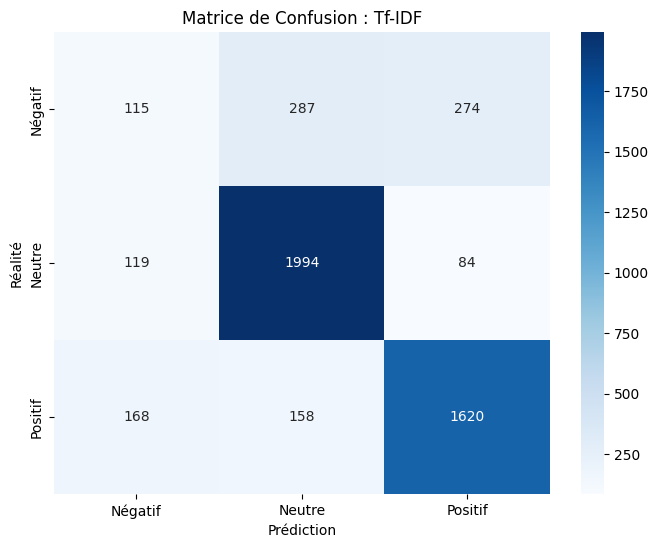

In [ ]:
cm = confusion_matrix(y_test_sa, tf_idf_pred_sa)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=sa_classes, yticklabels=sa_classes
)
plt.title('Matrice de Confusion : Tf-IDF')
plt.ylabel('Réalité')
plt.xlabel('Prédiction')
plt.show()

The performance is even better for sentiment analysis, considering only 3 classes

In [ ]:
tf_idf_sa_summary = pd.DataFrame(
    {
        'text_cleaned': X_test,
        'sentiment_reel': y_test_sa,
        'sentiment_ia': tf_idf_pred_sa,
        'verdict': np.where(tf_idf_pred_sa == y_test_sa, '✅ Correct', '❌ Erreur')
    },
)

tf_idf_sa_summary.head()

,text_cleaned,sentiment_reel,sentiment_ia,verdict
0,incompetent sale service repair partner exampl...,Négatif,Négatif,✅ Correct
1,avoid crazy simple register long exist militar...,Négatif,Négatif,✅ Correct
2,affordable price satisfied moment good custome...,Positif,Positif,✅ Correct
3,satisfied online membership service price corr...,Positif,Positif,✅ Correct
4,undersigned nathan steinbeck experience custom...,Neutre,Négatif,❌ Erreur


In [ ]:
# Calcul de la précision
accuracy = (tf_idf_sa_summary['sentiment_ia'] == tf_idf_sa_summary['sentiment_reel']).mean() * 100
print(f"\nPrécision sur cet échantillon : {accuracy:.2f}%")


Précision sur cet échantillon : 77.38%


In [ ]:
joblib.dump(tf_idf_clf_sa, "models/tf_idf_clf_sa.pkl")

['models/tf_idf_clf_sa.pkl']

## BERT Strategy

In [ ]:
# Fonction pour transformer les labels BERT en nos 3 catégories
def bert_to_sentiment(label):
    # Le modèle renvoie '1 star', '2 stars', etc.
    n_stars = int(label.split(' ')[0])
    return note_to_sentiment(n_stars)

In [ ]:
bert_pred_sa = [
    bert_to_sentiment(res['label'])
    for res in bert_test_pred # Predictions from BERT model
]

print("\nRésultats du classifieur :")
print(classification_report(y_test_sa, bert_pred_sa))


Résultats du classifieur :
              precision    recall  f1-score   support

      Neutre       0.25      0.10      0.14       676
     Négatif       0.81      0.86      0.84      2197
     Positif       0.75      0.85      0.80      1946

    accuracy                           0.75      4819
   macro avg       0.60      0.61      0.59      4819
weighted avg       0.71      0.75      0.72      4819



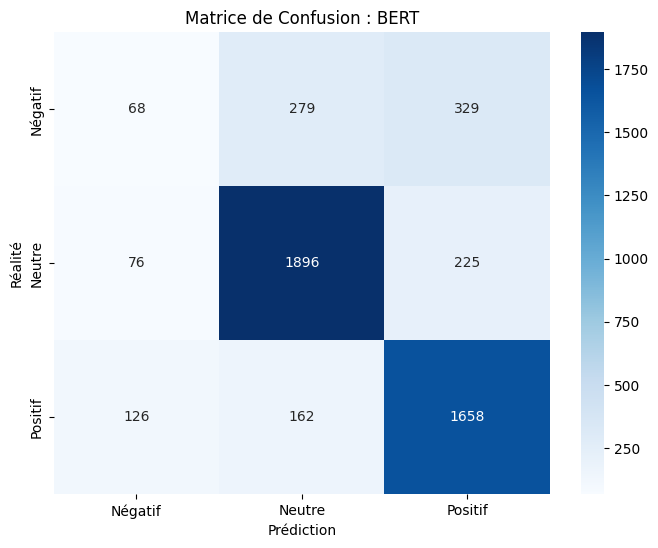

In [ ]:
cm = confusion_matrix(y_test_sa, bert_pred_sa)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=sa_classes, yticklabels=sa_classes
)
plt.title('Matrice de Confusion : BERT')
plt.ylabel('Réalité')
plt.xlabel('Prédiction')
plt.show()

In [ ]:
bert_sa_summary = pd.DataFrame(
    {
        'text_cleaned': X_test,
        'sentiment_reel': y_test_sa,
        'sentiment_ia': bert_pred_sa,
        'verdict': np.where(bert_pred_sa == y_test_sa, '✅ Correct', '❌ Erreur')
    },
)

bert_sa_summary.head()

,text_cleaned,sentiment_reel,sentiment_ia,verdict
0,incompetent sale service repair partner exampl...,Négatif,Négatif,✅ Correct
1,avoid crazy simple register long exist militar...,Négatif,Négatif,✅ Correct
2,affordable price satisfied moment good custome...,Positif,Positif,✅ Correct
3,satisfied online membership service price corr...,Positif,Positif,✅ Correct
4,undersigned nathan steinbeck experience custom...,Neutre,Neutre,✅ Correct


In [ ]:
# Calcul de la précision
accuracy = (bert_sa_summary['sentiment_ia'] == bert_sa_summary['sentiment_reel']).mean() * 100
print(f"\nPrécision sur cet échantillon : {accuracy:.2f}%")


Précision sur cet échantillon : 75.16%


## Autre LLM Sentiment

In [ ]:
# Fonction pour normaliser les labels (car le modèle renvoie 'positive', 'neutral', 'negative')
def normalize_sentiment_label(label):
    mapping = {
        'positive': 'Positif',
        'neutral': 'Neutre',
        'negative': 'Négatif'
    }
    return mapping.get(label, label)

In [ ]:
distil_sentiment = pipeline(
    "sentiment-analysis",
    model="lxyuan/distilbert-base-multilingual-cased-sentiments-student"
)

config.json:   0%|          | 0.00/759 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/541M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/373 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

In [ ]:
distilbert_test_pred = distil_sentiment(X_test, truncation=True, batch_size=run_batch_size)

distilbert_pred_sa = [
    normalize_sentiment_label(res['label'])
    for res in distilbert_test_pred # Predictions from Distil BERT model
]

print("\nRésultats du classifieur :")
print(classification_report(y_test_sa, distilbert_pred_sa))


Résultats du classifieur :
              precision    recall  f1-score   support

      Neutre       0.25      0.01      0.01       676
     Négatif       0.78      0.68      0.73      2197
     Positif       0.60      0.90      0.72      1946

    accuracy                           0.67      4819
   macro avg       0.54      0.53      0.49      4819
weighted avg       0.63      0.67      0.62      4819



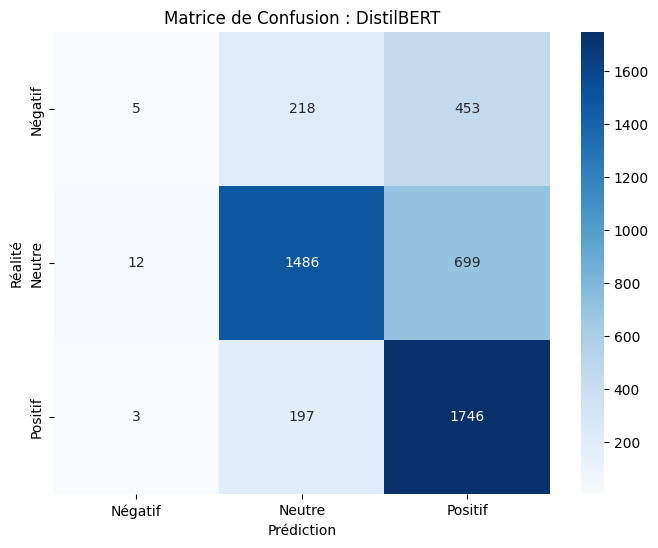

In [ ]:
cm = confusion_matrix(y_test_sa, distilbert_pred_sa)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=sa_classes, yticklabels=sa_classes
)
plt.title('Matrice de Confusion : DistilBERT')
plt.ylabel('Réalité')
plt.xlabel('Prédiction')
plt.show()

In [ ]:
distilbert_sa_summary = pd.DataFrame(
    {
        'text_cleaned': X_test,
        'sentiment_reel': y_test_sa,
        'sentiment_ia': distilbert_pred_sa,
        'verdict': np.where(distilbert_pred_sa == y_test_sa, '✅ Correct', '❌ Erreur')
    },
)

distilbert_sa_summary.head()

,text_cleaned,sentiment_reel,sentiment_ia,verdict
0,incompetent sale service repair partner exampl...,Négatif,Négatif,✅ Correct
1,avoid crazy simple register long exist militar...,Négatif,Négatif,✅ Correct
2,affordable price satisfied moment good custome...,Positif,Positif,✅ Correct
3,satisfied online membership service price corr...,Positif,Négatif,❌ Erreur
4,undersigned nathan steinbeck experience custom...,Neutre,Positif,❌ Erreur


In [ ]:
accuracy = (distilbert_sa_summary['sentiment_ia'] == distilbert_sa_summary['sentiment_reel']).mean() * 100
print(f"\nScore de cohérence : {accuracy:.2f}%")


Score de cohérence : 67.17%


Embedding Model

In [ ]:
y_train_sa = np.array([note_to_sentiment(int(n)) for n in y_train_ros])

In [ ]:
fe_clf_sa = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression())
])

fe_clf_sa.fit(deberta_X_train_features, y_train_sa)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Pipeline(steps=[('scaler', StandardScaler()), ('lr', LogisticRegression())])

In [ ]:
# 3. Évaluation
fe_clf_pred_sa = fe_clf_sa.predict(deberta_X_test_features)

print("\nRésultats du classifieur :")
print(classification_report(y_test_sa, fe_clf_pred_sa))


Résultats du classifieur :
              precision    recall  f1-score   support

      Neutre       0.17      0.07      0.10       676
     Négatif       0.70      0.80      0.74      2197
     Positif       0.67      0.71      0.69      1946

    accuracy                           0.66      4819
   macro avg       0.52      0.53      0.51      4819
weighted avg       0.62      0.66      0.63      4819



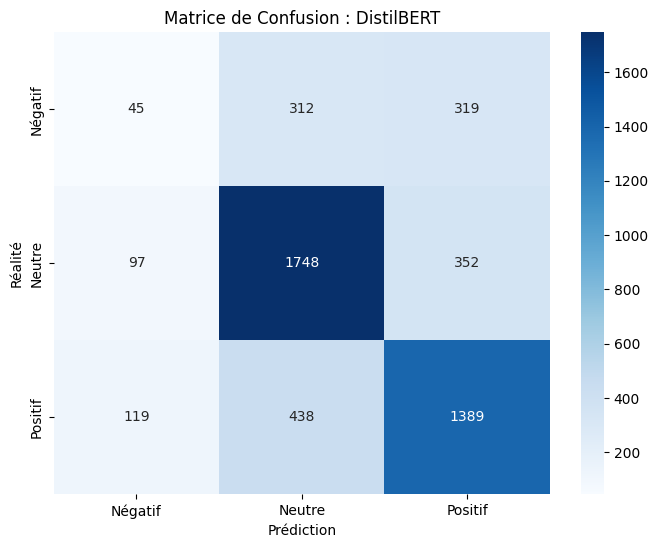

In [ ]:
cm = confusion_matrix(y_test_sa, fe_clf_pred_sa)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=sa_classes, yticklabels=sa_classes
)
plt.title('Matrice de Confusion : DistilBERT')
plt.ylabel('Réalité')
plt.xlabel('Prédiction')
plt.show()

In [ ]:
fe_clf_sa_summary = pd.DataFrame(
    {
        'text_cleaned': X_test,
        'sentiment_reel': y_test_sa,
        'sentiment_ia': fe_clf_pred_sa,
        'verdict': np.where(fe_clf_pred_sa == y_test_sa, '✅ Correct', '❌ Erreur')
    },
)

fe_clf_sa_summary.head()

,text_cleaned,sentiment_reel,sentiment_ia,verdict
0,incompetent sale service repair partner exampl...,Négatif,Négatif,✅ Correct
1,avoid crazy simple register long exist militar...,Négatif,Négatif,✅ Correct
2,affordable price satisfied moment good custome...,Positif,Positif,✅ Correct
3,satisfied online membership service price corr...,Positif,Positif,✅ Correct
4,undersigned nathan steinbeck experience custom...,Neutre,Négatif,❌ Erreur


In [ ]:
accuracy = (fe_clf_sa_summary['sentiment_ia'] == fe_clf_sa_summary['sentiment_reel']).mean() * 100
print(f"\nScore de cohérence : {accuracy:.2f}%")


Score de cohérence : 66.03%


From the above results, we can advance with the Tf-IDF model

# Subject Detection

We'll set our labels using a Huge LLM : Gemini

In [ ]:
import os
import time
from google import genai
from google.genai import types

from google.colab import userdata

In [ ]:
# 1. Initialize the list of possible categories
candidate_labels = [
    "Pricing",
    "Coverage",
    "Enrollment",
    "Customer Service",
    "Claims Processing",
    "Cancellation",
]

In [ ]:
os.environ["GOOGLE_API_KEY"] = userdata.get('google_api_key')

In [ ]:
client = genai.Client(api_key=os.environ.get("GOOGLE_API_KEY"))

In [ ]:
def classify_with_gemini(review_text, categories, model_name="gemini-2.0-flash"):
    if not isinstance(review_text, str) or not review_text.strip():
        return "Autre"

    prompt = f"Classifie cet avis dans l'une de ces catégories: {', '.join(categories)}. Avis: '{review_text}'. Réponds uniquement le nom de la catégorie."

    # On tente l'appel avec un système de retry simple
    max_retries = 3
    for attempt in range(max_retries):
        try:
            response = client.models.generate_content(
                model=model_name, # Note: 2.5 n'existe pas encore, reste sur 2.0 ou 1.5
                contents=prompt,
                config=types.GenerateContentConfig(temperature=0.1)
            )

            # Sécurité pour le NoneType
            if response and response.text:
                category_guessed = response.text.strip()
                # Validation
                for cat in categories:
                    if cat.lower() in category_guessed.lower():
                        return cat
                return "Autre"

        except Exception as e:
            if "429" in str(e):
                # Si quota dépassé, on attend plus longtemps
                print(f"Quota atteint, pause de 10s... (Essai {attempt+1}/{max_retries})")
                time.sleep(10)
            else:
                print(f"Erreur : {e}")
                break # Autre erreur, on sort de la boucle retry

    return "Erreur/Quota"

In [ ]:
# # 3. Apply the classification to X_train_ros to create y_train_subject
# print(f"Classifying {len(X_train_ros)} reviews using a placeholder for Gemini...")
# y_train_subject = [
#     classify_with_gemini(review, candidate_labels, model_name="gemini-2.0-flash")
#     for review in tqdm(X_train_ros)
# ]

# print("y_train_subject created successfully with placeholder categories.")
# print(f"First 5 subjects: {y_train_subject[:5]}")

In [ ]:
# print(f"Category counts: {Counter(y_train_subject)}")

In [ ]:
from sentence_transformers import SentenceTransformer, util

In [ ]:
# Chargement du modèle ultra-léger
model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2', device=device)

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
# Encodage des labels (une seule fois pour tout le projet !)
label_embeddings = model.encode(candidate_labels, convert_to_tensor=True)

In [ ]:
def classify_subjects(texts, model, threshold=0.1):
    """Fonction de détection par lot (Batch)"""
    # Encodage de tous les textes d'un coup
    text_embeddings = model.encode(texts, batch_size=64, convert_to_tensor=True, show_progress_bar=True)

    # Calcul de la proximité (similarité cosinus)
    cosine_scores = util.cos_sim(text_embeddings, label_embeddings)

    # On récupère le meilleur label et son score
    best_label_ids = torch.argmax(cosine_scores, dim=1).tolist()
    best_scores = torch.max(cosine_scores, dim=1).values.tolist()

    subjects = []
    for i, label_id in enumerate(best_label_ids):
        # Le meilleur score doit être supérieur au seuil, sinon on considère <Other>
        if best_scores[i] >= threshold:
            subjects.append(candidate_labels[label_id])
        else:
            subjects.append("Other")
    return subjects, best_scores

In [ ]:
print(f"Analyse de {df.shape[0]} avis...")

# Application
texts = df['text_cleaned'].fillna("").astype(str).tolist()
df['subject'], df['score'] = classify_subjects(texts, model)

Analyse de 24092 avis...


Batches:   0%|          | 0/377 [00:00<?, ?it/s]

In [ ]:
df[['text_cleaned', 'subject', 'score']].head()

,text_cleaned,subject,score
0,olivi assurance give quote announce price sign...,Pricing,0.359870
1,axe big big concern site week unable promise r...,Customer Service,0.377086
2,satisfied service price attractive warm welcom...,Customer Service,0.462484
3,painful registration lose document read comple...,Customer Service,0.313743
4,response day month request sinister electric p...,Other,0.061613


# Save final data

In [ ]:
df['sentiment'] = df['note'].map(note_to_sentiment)

In [ ]:
df.columns

Index(['note', 'auteur', 'avis', 'assureur', 'produit', 'type',
       'date_publication', 'date_exp', 'avis_en', 'avis_cor', 'avis_cor_en',
       'text_cleaned', 'subject', 'score', 'sentiment'],
      dtype='object')

In [ ]:
df.to_csv("data/final_data.csv", index=False)

In [ ]:
df = pd.read_csv("data/final_data.csv")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24092 entries, 0 to 24091
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   note              24092 non-null  float64
 1   auteur            24091 non-null  object 
 2   avis              24092 non-null  object 
 3   assureur          24092 non-null  object 
 4   produit           24092 non-null  object 
 5   type              24092 non-null  object 
 6   date_publication  24092 non-null  object 
 7   date_exp          24092 non-null  object 
 8   avis_en           24092 non-null  object 
 9   avis_cor          0 non-null      float64
 10  avis_cor_en       0 non-null      float64
 11  text_cleaned      24092 non-null  object 
 12  subject           24092 non-null  object 
 13  score             24092 non-null  float64
 14  sentiment         24092 non-null  object 
dtypes: float64(4), object(11)
memory usage: 2.8+ MB


# Streamlit app

In [ ]:
!npm install -g localtunnel

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇
added 22 packages in 5s
⠇
⠇3 packages are looking for funding
⠇  run `npm fund` for details
⠇

In [ ]:
%%writefile app.py
"""
Insurance Review NLP - Application Streamlit
Analyse de sentiments, prédiction de notes et détection de sujets
sur des avis clients dans le secteur de l'assurance.
"""

import streamlit as st
import pandas as pd
import numpy as np
import re
import io
import os
import zipfile
import glob
from collections import Counter

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# ─── PAGE CONFIG ────────────────────────────────────────────────────────────
st.set_page_config(
    page_title="Insurance NLP Dashboard",
    page_icon="🛡️",
    layout="wide",
    initial_sidebar_state="expanded",
)

# ─── CUSTOM CSS ─────────────────────────────────────────────────────────────
st.markdown("""
<style>
@import url('https://fonts.googleapis.com/css2?family=Syne:wght@400;700;800&family=DM+Mono:wght@400;500&family=DM+Sans:wght@300;400;500&display=swap');

/* Global */
html, body, [class*="css"] {
    font-family: 'DM Sans', sans-serif;
}

/* Fond principal */
.stApp {
    background: #0f0f14;
    color: #e8e4dc;
}

/* Sidebar */
[data-testid="stSidebar"] {
    background: #16161e !important;
    border-right: 1px solid #2a2a38;
}

/* Titres */
h1, h2, h3 {
    font-family: 'Syne', sans-serif !important;
    letter-spacing: -0.02em;
}

/* Hero header */
.hero-header {
    background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%);
    border: 1px solid #2d4a7a;
    border-radius: 16px;
    padding: 40px 48px;
    margin-bottom: 32px;
    position: relative;
    overflow: hidden;
}
.hero-header::before {
    content: '';
    position: absolute;
    top: -50%;
    right: -10%;
    width: 400px;
    height: 400px;
    background: radial-gradient(circle, rgba(99,179,237,0.08) 0%, transparent 70%);
    border-radius: 50%;
}
.hero-title {
    font-family: 'Syne', sans-serif;
    font-size: 2.8rem;
    font-weight: 800;
    color: #e8e4dc;
    margin: 0;
    line-height: 1.1;
}
.hero-subtitle {
    color: #63b3ed;
    font-family: 'DM Mono', monospace;
    font-size: 0.85rem;
    margin-top: 8px;
    letter-spacing: 0.05em;
    text-transform: uppercase;
}

/* Metric cards */
.metric-card {
    background: #1a1a26;
    border: 1px solid #2a2a3a;
    border-radius: 12px;
    padding: 20px 24px;
    text-align: center;
    transition: border-color 0.2s;
}
.metric-card:hover { border-color: #63b3ed; }
.metric-value {
    font-family: 'Syne', sans-serif;
    font-size: 2.4rem;
    font-weight: 800;
    color: #63b3ed;
    line-height: 1;
}
.metric-label {
    font-size: 0.8rem;
    color: #888;
    text-transform: uppercase;
    letter-spacing: 0.08em;
    margin-top: 4px;
    font-family: 'DM Mono', monospace;
}

/* Section headers */
.section-title {
    font-family: 'Syne', sans-serif;
    font-size: 1.4rem;
    font-weight: 700;
    color: #e8e4dc;
    border-left: 3px solid #63b3ed;
    padding-left: 16px;
    margin: 32px 0 16px;
}

/* Sentiment badges */
.badge-pos {
    background: rgba(72,199,142,0.15);
    color: #48c78e;
    border: 1px solid rgba(72,199,142,0.3);
    border-radius: 6px;
    padding: 2px 10px;
    font-family: 'DM Mono', monospace;
    font-size: 0.8rem;
    font-weight: 500;
}
.badge-neu {
    background: rgba(255,189,89,0.15);
    color: #ffbd59;
    border: 1px solid rgba(255,189,89,0.3);
    border-radius: 6px;
    padding: 2px 10px;
    font-family: 'DM Mono', monospace;
    font-size: 0.8rem;
}
.badge-neg {
    background: rgba(255,100,100,0.15);
    color: #ff6b6b;
    border: 1px solid rgba(255,100,100,0.3);
    border-radius: 6px;
    padding: 2px 10px;
    font-family: 'DM Mono', monospace;
    font-size: 0.8rem;
}

/* Prediction result box */
.prediction-box {
    background: linear-gradient(135deg, #1a1a26, #1e1e2e);
    border: 1px solid #2a2a3a;
    border-radius: 12px;
    padding: 28px 32px;
    text-align: center;
}
.star-display {
    font-size: 3rem;
    line-height: 1;
}
.stars-score {
    font-family: 'Syne', sans-serif;
    font-size: 1.8rem;
    font-weight: 800;
    color: #ffd700;
    margin-top: 8px;
}

/* Tabs */
.stTabs [data-baseweb="tab-list"] {
    background: #1a1a26;
    border-radius: 10px;
    padding: 4px;
    gap: 4px;
}
.stTabs [data-baseweb="tab"] {
    background: transparent;
    color: #888;
    border-radius: 8px;
    font-family: 'DM Mono', monospace;
    font-size: 0.85rem;
}
.stTabs [aria-selected="true"] {
    background: #2a2a3a !important;
    color: #63b3ed !important;
}

/* Plotly charts dark background override */
.js-plotly-plot .plotly { background: transparent !important; }

/* File uploader */
[data-testid="stFileUploader"] {
    background: #1a1a26;
    border: 2px dashed #2a2a3a;
    border-radius: 12px;
    padding: 16px;
}

/* Scrollbar */
::-webkit-scrollbar { width: 6px; }
::-webkit-scrollbar-track { background: #0f0f14; }
::-webkit-scrollbar-thumb { background: #2a2a3a; border-radius: 3px; }
</style>
""", unsafe_allow_html=True)

# ─── PLOTLY DARK THEME ───────────────────────────────────────────────────────
PLOTLY_LAYOUT = dict(
    paper_bgcolor="rgba(0,0,0,0)",
    plot_bgcolor="rgba(0,0,0,0)",
    font=dict(family="DM Mono, monospace", color="#e8e4dc", size=12),
    title_font=dict(family="Syne, sans-serif", size=16, color="#e8e4dc"),
    # xaxis=dict(gridcolor="#2a2a3a", linecolor="#2a2a3a", tickcolor="#555"),
    # yaxis=dict(gridcolor="#2a2a3a", linecolor="#2a2a3a", tickcolor="#555"),
    margin=dict(l=20, r=20, t=40, b=20),
)

PALETTE_BLUE = ["#1a3a5c", "#1e4d7b", "#2563a8", "#3b82f6", "#63b3ed", "#93c5fd", "#bfdbfe"]
PALETTE_SENT = {"Positif": "#48c78e", "Neutre": "#ffbd59", "Négatif": "#ff6b6b"}

# ─── HELPERS ─────────────────────────────────────────────────────────────────

device = 0 if torch.cuda.is_available() else -1

def note_to_sentiment(note):
    note = int(note)
    if note <= 2: return "Négatif"
    elif note == 3: return "Neutre"
    return "Positif"

def stars(note):
    n = int(note)
    return "⭐" * n + "☆" * (5 - n)

@st.cache_resource
def load_nlp_tools():
    import spacy
    from spellchecker import SpellChecker
    spell = SpellChecker(language="en")
    try:
        nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])
    except OSError:
        import subprocess
        subprocess.run(["python", "-m", "spacy", "download", "en_core_web_sm"], check=True)
        nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])
    return spell, nlp

@st.cache_resource
def load_tfidf_mark_model():
    """Load or train a TF-IDF model. Returns None if no training data."""
    import joblib
    model_path = "models/tf_idf_clf_mark.pkl"
    if os.path.exists(model_path):
        return joblib.load(model_path)
    return None

@st.cache_resource
def load_tfidf_sa_model():
    """Load or train a TF-IDF model. Returns None if no training data."""
    import joblib
    model_path = "models/tf_idf_clf_sa.pkl"
    if os.path.exists(model_path):
        return joblib.load(model_path)
    return None

@st.cache_resource
def load_bert_sentiment():
    from transformers import pipeline as hf_pipeline
    return hf_pipeline(
        "sentiment-analysis",
        model="nlptown/bert-base-multilingual-uncased-sentiment",
    )

@st.cache_resource
def load_distilbert_sentiment():
    from transformers import pipeline as hf_pipeline
    return hf_pipeline(
        "sentiment-analysis",
        model="lxyuan/distilbert-base-multilingual-cased-sentiments-student",
    )

@st.cache_resource
def load_sentence_transformer():
    from sentence_transformers import SentenceTransformer
    return SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

CANDIDATE_LABELS = ["Pricing", "Coverage", "Enrollment",
                    "Customer Service", "Claims Processing", "Cancellation"]

def clean_text(text: str, spell, nlp) -> str:
    if not isinstance(text, str) or not text.strip():
        return ""
    text = text.lower()
    text = re.sub(r"[^a-z ]", " ", text)
    words = text.split()
    cache = {}
    corrected = []
    for w in words:
        if w not in cache:
            if w in spell.unknown([w]):
                sugg = spell.correction(w)
                cache[w] = sugg if sugg else w
            else:
                cache[w] = w
        corrected.append(cache[w])
    doc = nlp(" ".join(corrected))
    return " ".join([t.lemma_ for t in doc if not t.is_stop and len(t.text) > 2])

def load_df_from_upload(uploaded_files):
    dfs = []
    for f in uploaded_files:
        ext = f.name.lower()
        if ext.endswith(".xlsx") or ext.endswith(".xls"):
            dfs.append(pd.read_excel(f))
        elif ext.endswith(".csv"):
            dfs.append(pd.read_csv(f))
        elif ext.endswith(".zip"):
            with zipfile.ZipFile(f) as zf:
                for name in zf.namelist():
                    if name.endswith(".xlsx"):
                        with zf.open(name) as inner:
                            dfs.append(pd.read_excel(inner))
                    elif name.endswith(".csv"):
                        with zf.open(name) as inner:
                            dfs.append(pd.read_csv(inner))
    if not dfs:
        return None
    return pd.concat(dfs, ignore_index=True)

def classify_subjects(texts, model, threshold=0.1):
    """Fonction de détection par lot (Batch)"""
    # Encodage de tous les labels d'un coup
    label_embeddings = model.encode(CANDIDATE_LABELS, batch_size=64, convert_to_tensor=True, show_progress_bar=False)
    # Encodage de tous les textes d'un coup
    text_embeddings = model.encode(texts, batch_size=64, convert_to_tensor=True, show_progress_bar=False)

    # Calcul de la proximité (similarité cosinus)
    cosine_scores = util.cos_sim(text_embeddings, label_embeddings)

    # On récupère le meilleur label et son score
    best_label_ids = torch.argmax(cosine_scores, dim=1).tolist()
    best_scores = torch.max(cosine_scores, dim=1).values.tolist()

    subjects = []
    for i, label_id in enumerate(best_label_ids):
        # Le meilleur score doit être supérieur au seuil, sinon on considère <Other>
        if best_scores[i] >= threshold:
            subjects.append(candidate_labels[label_id])
        else:
            subjects.append("Other")
    return subjects, best_scores

# ─── SIDEBAR ─────────────────────────────────────────────────────────────────
with st.sidebar:
    st.markdown("<div style='padding: 8px 0;'>", unsafe_allow_html=True)
    st.markdown("### 🛡️ Insurance NLP")
    st.markdown("<hr style='border-color:#2a2a3a; margin:8px 0 20px'>", unsafe_allow_html=True)

    st.markdown("#### 📂 Charger des données")
    uploaded_files = st.file_uploader(
        "Fichiers xlsx, csv ou zip",
        type=["xlsx", "xls", "csv", "zip"],
        accept_multiple_files=True,
        help="Vos fichiers doivent contenir les colonnes 'avis_en' et 'note'."
    )

    st.markdown("<hr style='border-color:#2a2a3a; margin:20px 0'>", unsafe_allow_html=True)

    use_preloaded = st.checkbox("Utiliser données de démo", value=not bool(uploaded_files))

    st.markdown("<hr style='border-color:#2a2a3a; margin:20px 0'>", unsafe_allow_html=True)
    st.markdown("#### ⚙️ Modèles NLP")
    run_spellcheck = st.checkbox("Correction orthographique", value=False,
                                 help="Ralentit le traitement mais améliore la qualité")
    text_col = st.text_input("Colonne texte", value="avis_en")
    note_col = st.text_input("Colonne note (1-5)", value="note")

    st.markdown("<hr style='border-color:#2a2a3a; margin:20px 0'>", unsafe_allow_html=True)
    st.caption("Insurance NLP Dashboard · v1.0")

# ─── DEMO DATA ───────────────────────────────────────────────────────────────
# DEMO_REVIEWS = [
#     {"avis_en": "Excellent coverage and very responsive customer service. Claims were processed quickly.", "note": 5},
#     {"avis_en": "The pricing is too high compared to competitors. Not worth the cost.", "note": 2},
#     {"avis_en": "Enrollment process was straightforward. Happy with the coverage options.", "note": 4},
#     {"avis_en": "My claim was denied without clear explanation. Very disappointing experience.", "note": 1},
#     {"avis_en": "Average service, nothing special. The policy covers what I need.", "note": 3},
#     {"avis_en": "Fast claim processing and fair settlement. Would recommend to friends.", "note": 5},
#     {"avis_en": "Cancellation process was a nightmare. Took months and multiple calls.", "note": 1},
#     {"avis_en": "Good value for money. Customer service agents are helpful and knowledgeable.", "note": 4},
#     {"avis_en": "Premium increased significantly without notice. Looking for alternatives.", "note": 2},
#     {"avis_en": "Smooth enrollment and clear policy documents. Very satisfied overall.", "note": 4},
#     {"avis_en": "Claims department is slow and unresponsive. Waited 3 months for settlement.", "note": 2},
#     {"avis_en": "Great coverage options at competitive prices. Highly recommend.", "note": 5},
#     {"avis_en": "Neutral experience. Policy is adequate but nothing outstanding.", "note": 3},
#     {"avis_en": "Terrible customer support. They never answer the phone.", "note": 1},
#     {"avis_en": "Very happy with the service. Claims handled professionally and fast.", "note": 5},
#     {"avis_en": "Pricing is reasonable and coverage is comprehensive.", "note": 4},
#     {"avis_en": "Enrollment took too long. Paperwork was excessive and confusing.", "note": 2},
#     {"avis_en": "Outstanding service! The team helped me through every step of my claim.", "note": 5},
#     {"avis_en": "Average experience. The coverage meets minimum requirements.", "note": 3},
#     {"avis_en": "Difficult to cancel. They kept charging me after I requested cancellation.", "note": 1},
# ]

@st.cache_data
def make_demo_df():
    return pd.read_csv("data/final_data.csv")

    # df = pd.DataFrame(DEMO_REVIEWS)
    # df["text_cleaned"] = df["avis_en"].str.lower().str.replace(r"[^a-z ]", " ", regex=True)
    # df["sentiment"] = df["note"].apply(note_to_sentiment)
    # # Simple subject detection based on keywords
    # subject_map = {
    #     "claim": "Claims Processing", "claims": "Claims Processing",
    #     "price": "Pricing", "pricing": "Pricing", "premium": "Pricing", "cost": "Pricing",
    #     "cover": "Coverage", "coverage": "Coverage", "policy": "Coverage",
    #     "enroll": "Enrollment", "enrollment": "Enrollment",
    #     "customer": "Customer Service", "support": "Customer Service", "service": "Customer Service",
    #     "cancel": "Cancellation", "cancellation": "Cancellation",
    # }
    # def detect_subject(text):
    #     text = text.lower()
    #     for kw, cat in subject_map.items():
    #         if kw in text:
    #             return cat
    #     return "Coverage"
    # df["subject"] = df["avis_en"].apply(detect_subject)
    # return df

# ─── MAIN ─────────────────────────────────────────────────────────────────────

# Hero
st.markdown("""
<div class="hero-header">
    <div class="hero-title">🛡️ Insurance Review<br>NLP Dashboard</div>
    <div class="hero-subtitle">Analyse de sentiments · Prédiction de notes · Détection de sujets</div>
</div>
""", unsafe_allow_html=True)

# Load data
df = None
if uploaded_files:
    with st.spinner("Chargement des fichiers..."):
        df = load_df_from_upload(uploaded_files)
    if df is not None:
        if text_col not in df.columns:
            st.error(f"Colonne '{text_col}' introuvable. Colonnes disponibles : {list(df.columns)}")
            df = None
        else:
            df.dropna(subset=[text_col], inplace=True)
            df = df[df[text_col].str.len() > 2]
            df.reset_index(drop=True, inplace=True)
            if note_col in df.columns:
                df.dropna(subset=[note_col], inplace=True)
                df["sentiment"] = df[note_col].apply(note_to_sentiment)
            if "text_cleaned" not in df.columns:
                df["text_cleaned"] = df[text_col].map(clean_text)
            if "subject" not in df.columns:
                df['subject'], df['score'] = classify_subjects(df, 'text_cleaned', model)
            st.success(f"✅ {len(df)} avis chargés depuis vos fichiers.")

if df is None or use_preloaded:
    df = make_demo_df()
    if not uploaded_files:
        st.info("💡 Mode démo — chargez vos propres fichiers dans la barre latérale.")

# ─── METRICS ──────────────────────────────────────────────────────────────────
col1, col2, col3, col4, col5 = st.columns(5)
n_pos = (df["sentiment"] == "Positif").sum() if "sentiment" in df.columns else 0
n_neu = (df["sentiment"] == "Neutre").sum() if "sentiment" in df.columns else 0
n_neg = (df["sentiment"] == "Négatif").sum() if "sentiment" in df.columns else 0
avg_note = df[note_col].mean() if note_col in df.columns else 0

metrics = [
    (len(df), "Avis total"),
    (f"{avg_note:.2f}" if avg_note else "–", "Note moyenne"),
    (n_pos, "😊 Positifs"),
    (n_neu, "😐 Neutres"),
    (n_neg, "😞 Négatifs"),
]
for col_st, (val, label) in zip([col1, col2, col3, col4, col5], metrics):
    with col_st:
        st.markdown(f"""
        <div class="metric-card">
            <div class="metric-value">{val}</div>
            <div class="metric-label">{label}</div>
        </div>
        """, unsafe_allow_html=True)

st.markdown("<br>", unsafe_allow_html=True)

# ─── TABS ─────────────────────────────────────────────────────────────────────
tab1, tab2, tab3, tab4, tab5, tab6 = st.tabs([
    "📊 Vue d'ensemble",
    "☁️ Nuage de mots",
    "🔮 Prédire une note",
    "💬 Analyser un avis",
    "📋 Données brutes",
    "🔍 Rechercher un avis",
])

# ─────────────────────── TAB 1 : VUE D'ENSEMBLE ──────────────────────────────
with tab1:
    col_a, col_b = st.columns([1, 1], gap="large")

    with col_a:
        st.markdown('<div class="section-title">Distribution des notes</div>', unsafe_allow_html=True)
        if note_col in df.columns:
            note_counts = df[note_col].value_counts().sort_index()
            fig_notes = go.Figure(go.Bar(
                x=[str(int(n)) for n in note_counts.index],
                y=note_counts.values,
                marker=dict(
                    color=note_counts.values,
                    colorscale=[[0, "#1a3a5c"], [0.5, "#3b82f6"], [1, "#63b3ed"]],
                    line=dict(color="#0f0f14", width=2),
                ),
                text=note_counts.values,
                textposition="outside",
                textfont=dict(color="#e8e4dc", family="DM Mono"),
            ))
            fig_notes.update_layout(**PLOTLY_LAYOUT, height=320,
                                    xaxis_title="Note (1 à 5)", yaxis_title="Nombre d'avis")
            st.plotly_chart(fig_notes, use_container_width=True)
        else:
            st.warning(f"Colonne '{note_col}' introuvable dans les données.")

    with col_b:
        st.markdown('<div class="section-title">Répartition des sentiments</div>', unsafe_allow_html=True)
        if "sentiment" in df.columns:
            sent_counts = df["sentiment"].value_counts()
            fig_sent = go.Figure(go.Pie(
                labels=sent_counts.index.tolist(),
                values=sent_counts.values.tolist(),
                hole=0.55,
                marker=dict(
                    colors=[PALETTE_SENT.get(s, "#888") for s in sent_counts.index],
                    line=dict(color="#0f0f14", width=3),
                ),
                textfont=dict(family="DM Mono", color="#e8e4dc"),
            ))
            fig_sent.update_layout(**PLOTLY_LAYOUT, height=320,
                                   showlegend=True,
                                   legend=dict(font=dict(family="DM Mono", color="#e8e4dc")))
            st.plotly_chart(fig_sent, use_container_width=True)

    # Top 20 mots
    st.markdown('<div class="section-title">Top 20 mots les plus fréquents</div>', unsafe_allow_html=True)
    if "text_cleaned" in df.columns:
        all_words = " ".join(df["text_cleaned"].astype(str)).split()
        word_freq = Counter(w for w in all_words if len(w) > 2)
        common = word_freq.most_common(20)
        words_list = [w for w, _ in common]
        counts_list = [c for _, c in common]

        fig_words = go.Figure(go.Bar(
            x=counts_list[::-1],
            y=words_list[::-1],
            orientation="h",
            marker=dict(
                color=counts_list[::-1],
                colorscale=[[0, "#1a3a5c"], [1, "#63b3ed"]],
                line=dict(color="#0f0f14", width=1),
            ),
            text=counts_list[::-1],
            textposition="outside",
            textfont=dict(family="DM Mono", color="#e8e4dc", size=11),
        ))
        fig_words.update_layout(**PLOTLY_LAYOUT, height=480,
                                xaxis_title="Fréquence", yaxis_title="",
                                yaxis=dict(tickfont=dict(family="DM Mono", size=12)))
        st.plotly_chart(fig_words, use_container_width=True)

    # Sujets
    if "subject" in df.columns and df["subject"].nunique() > 1:
        st.markdown('<div class="section-title">Détection de sujets</div>', unsafe_allow_html=True)
        col_s1, col_s2 = st.columns([1, 1], gap="large")
        with col_s1:
            subj_counts = df["subject"].value_counts()
            fig_subj = go.Figure(go.Bar(
                x=subj_counts.index.tolist(),
                y=subj_counts.values.tolist(),
                marker=dict(color=PALETTE_BLUE[:len(subj_counts)],
                            line=dict(color="#0f0f14", width=2)),
                text=subj_counts.values.tolist(),
                textposition="outside",
                textfont=dict(color="#e8e4dc", family="DM Mono"),
            ))
            fig_subj.update_layout(**PLOTLY_LAYOUT, height=320,
                                   xaxis_title="Catégorie", yaxis_title="Nombre d'avis",
                                   xaxis=dict(tickangle=-25))
            st.plotly_chart(fig_subj, use_container_width=True)

        with col_s2:
            if note_col in df.columns:
                subj_note = df.groupby("subject")[note_col].mean().sort_values()
                fig_subj_note = go.Figure(go.Bar(
                    x=subj_note.values,
                    y=subj_note.index.tolist(),
                    orientation="h",
                    marker=dict(
                        color=subj_note.values,
                        colorscale=[[0, "#ff6b6b"], [0.5, "#ffbd59"], [1, "#48c78e"]],
                        cmin=1, cmax=5,
                        line=dict(color="#0f0f14", width=1),
                    ),
                    text=[f"{v:.2f}" for v in subj_note.values],
                    textposition="outside",
                    textfont=dict(family="DM Mono", color="#e8e4dc"),
                ))
                fig_subj_note.update_layout(**PLOTLY_LAYOUT, height=320,
                                            xaxis_title="Note moyenne", xaxis=dict(range=[0, 5.5]))
                st.plotly_chart(fig_subj_note, use_container_width=True)

# ─────────────────────── TAB 2 : NUAGE DE MOTS ───────────────────────────────
with tab2:
    st.markdown('<div class="section-title">Nuage de mots</div>', unsafe_allow_html=True)

    col_wc1, col_wc2 = st.columns([2, 1])
    with col_wc2:
        colormap_choice = st.selectbox("Palette", ["plasma", "viridis", "magma", "cool", "Blues"])
        max_words_wc = st.slider("Nombre de mots max", 30, 200, 100)
        filter_sentiment_wc = st.selectbox("Filtrer par sentiment",
                                           ["Tous", "Positif", "Neutre", "Négatif"])

    with col_wc1:
        try:
            from wordcloud import WordCloud
            subset = df
            if filter_sentiment_wc != "Tous" and "sentiment" in df.columns:
                subset = df[df["sentiment"] == filter_sentiment_wc]
            full_text = " ".join(subset["text_cleaned"].astype(str))
            if len(full_text.strip()) > 10:
                wc = WordCloud(
                    width=900, height=420,
                    background_color=None,
                    mode="RGBA",
                    colormap=colormap_choice,
                    max_words=max_words_wc,
                    prefer_horizontal=0.8,
                ).generate(full_text)
                fig_wc, ax_wc = plt.subplots(figsize=(9, 4.2))
                fig_wc.patch.set_facecolor("none")
                ax_wc.set_facecolor("none")
                ax_wc.imshow(wc, interpolation="bilinear")
                ax_wc.axis("off")
                st.pyplot(fig_wc)
            else:
                st.info("Pas assez de texte pour générer un nuage de mots.")
        except ImportError:
            st.warning("Package `wordcloud` non installé. Installez-le avec : `pip install wordcloud`")

# ─────────────────────── TAB 3 : PRÉDIRE UNE NOTE ────────────────────────────
with tab3:
    st.markdown('<div class="section-title">Prédiction de note (TF-IDF)</div>', unsafe_allow_html=True)
    st.caption("Le modèle TF-IDF + Régression Logistique prédit une note de 1 à 5 étoiles.")

    col_p1, col_p2 = st.columns([2, 1], gap="large")
    with col_p1:
        input_review = st.text_area(
            "Saisissez un avis client (en anglais)",
            placeholder="e.g. The claims process was incredibly slow and frustrating...",
            height=150,
        )
        predict_btn = st.button("🔮 Prédire la note", use_container_width=True, type="primary")

    with col_p2:
        st.markdown('<div class="prediction-box" id="pred-box">', unsafe_allow_html=True)
        placeholder_pred = st.empty()
        placeholder_pred.markdown("""
        <div style="text-align:center; color:#555; padding: 20px 0;">
            <div style="font-size:3rem">🔮</div>
            <div style="font-family:'DM Mono'; font-size:0.85rem; margin-top:8px;">
                En attente d'un avis...
            </div>
        </div>
        """, unsafe_allow_html=True)
        st.markdown("</div>", unsafe_allow_html=True)

    if predict_btn and input_review.strip():
        with st.spinner("Analyse en cours..."):
            # Try to load saved model first
            tfidf_model = load_tfidf_mark_model()

            if tfidf_model is None:
                # Train on demo data inline
                from sklearn.pipeline import Pipeline
                from sklearn.feature_extraction.text import TfidfVectorizer
                from sklearn.linear_model import LogisticRegression
                demo_df = make_demo_df()
                X_train_demo = demo_df["text_cleaned"].tolist()
                y_train_demo = demo_df["note"].tolist()
                tfidf_model = Pipeline([
                    ("tfidf", TfidfVectorizer(max_features=2000, stop_words="english")),
                    ("clf", LogisticRegression(max_iter=1000)),
                ])
                tfidf_model.fit(X_train_demo, y_train_demo)

            # Clean & predict
            clean = clean_text(input_review)
            predicted_note = int(tfidf_model.predict([clean])[0])
            sentiment = note_to_sentiment(predicted_note)
            badge_class = {"Positif": "badge-pos", "Neutre": "badge-neu", "Négatif": "badge-neg"}[sentiment]

        placeholder_pred.markdown(f"""
        <div style="text-align:center;">
            <div style="font-size:3rem">{stars(predicted_note)}</div>
            <div class="stars-score">{predicted_note} / 5</div>
            <div style="margin-top:12px;">
                <span class="{badge_class}">{sentiment}</span>
            </div>
            <div style="font-family:'DM Mono'; font-size:0.75rem; color:#555; margin-top:12px;">
                Modèle : TF-IDF + LogReg
            </div>
        </div>
        """, unsafe_allow_html=True)

        # Show proba bar chart if probabilities available
        try:
            proba = tfidf_model.predict_proba([clean])[0]
            classes = tfidf_model.classes_
            fig_proba = go.Figure(go.Bar(
                x=[f"⭐ {int(c)}" for c in classes],
                y=proba,
                marker=dict(
                    color=proba,
                    colorscale=[[0, "#1a3a5c"], [1, "#63b3ed"]],
                    line=dict(color="#0f0f14", width=2),
                ),
                text=[f"{p:.0%}" for p in proba],
                textposition="outside",
                textfont=dict(color="#e8e4dc", family="DM Mono"),
            ))
            fig_proba.update_layout(**PLOTLY_LAYOUT, height=260,
                                    title="Probabilité par note",
                                    yaxis=dict(tickformat=".0%", range=[0, max(proba) * 1.3]))
            st.plotly_chart(fig_proba, use_container_width=True)
        except Exception:
            pass

# ─────────────────────── TAB 4 : ANALYSER UN AVIS ────────────────────────────
with tab4:
    st.markdown('<div class="section-title">Analyse de sentiment en temps réel</div>', unsafe_allow_html=True)
    st.caption("Entrez un avis pour obtenir une analyse de sentiment instantanée.")

    input_sa = st.text_area(
        "Avis à analyser",
        placeholder="e.g. Great insurance company, very helpful staff and fast claims...",
        height=130,
        key="sa_input",
    )
    model_choice = st.radio("Méthode d'analyse",
                             ["Règles simples (rapide)", "DistilBERT (IA)"],
                             horizontal=True)
    analyze_btn = st.button("💬 Analyser le sentiment", use_container_width=True, type="primary")

    if analyze_btn and input_sa.strip():
        with st.spinner("Analyse en cours..."):
            if model_choice == "Règles simples (rapide)":
                pos_kw = ["great", "excellent", "fast", "helpful", "recommend", "happy",
                          "satisfied", "good", "outstanding", "love", "perfect", "amazing"]
                neg_kw = ["terrible", "awful", "slow", "nightmare", "frustrating", "denied",
                          "disappointment", "bad", "horrible", "worst", "useless", "avoid"]
                text_lower = input_sa.lower()
                pos_hits = sum(1 for k in pos_kw if k in text_lower)
                neg_hits = sum(1 for k in neg_kw if k in text_lower)
                if pos_hits > neg_hits:
                    label, score = "Positif", min(0.5 + 0.1 * pos_hits, 0.99)
                elif neg_hits > pos_hits:
                    label, score = "Négatif", min(0.5 + 0.1 * neg_hits, 0.99)
                else:
                    label, score = "Neutre", 0.6
                model_name_display = "Règles lexicales"
            else:
                try:
                    # distilbert = load_distilbert_sentiment()
                    # result = distilbert(input_sa[:512], truncation=True)[0]
                    # raw_label = result["label"].lower()
                    # score = result["score"]
                    # mapping = {"positive": "Positif", "neutral": "Neutre", "negative": "Négatif"}
                    # label = mapping.get(raw_label, "Neutre")
                    # model_name_display = "DistilBERT multilingue"
                    model_name_display = "TfIDF"
                    tf_idf_clf_sa = load_tf_idf_sa()
                    label = tf_idf_clf_sa.predict([input_sa])[0]
                except Exception as e:
                    st.error(f"Erreur modèle IA : {e}. Utilisation des règles simples.")
                    label, score = "Neutre", 0.5
                    model_name_display = "Règles lexicales (fallback)"

        badge_class = {"Positif": "badge-pos", "Neutre": "badge-neu", "Négatif": "badge-neg"}[label]
        emoji = {"Positif": "😊", "Neutre": "😐", "Négatif": "😞"}[label]
        color = {"Positif": "#48c78e", "Neutre": "#ffbd59", "Négatif": "#ff6b6b"}[label]

        col_r1, col_r2 = st.columns([1, 2], gap="large")
        with col_r1:
            st.markdown(f"""
            <div class="prediction-box">
                <div style="font-size:3.5rem">{emoji}</div>
                <div style="font-family:'Syne'; font-size:1.6rem; font-weight:800;
                            color:{color}; margin-top:8px;">{label}</div>
                <div style="font-family:'DM Mono'; font-size:0.85rem; color:#888;
                            margin-top:6px;">Confiance : {score:.0%}</div>
                <div style="font-family:'DM Mono'; font-size:0.72rem; color:#555;
                            margin-top:10px;">Modèle : {model_name_display}</div>
            </div>
            """, unsafe_allow_html=True)

        with col_r2:
            # Gauge chart for confidence
            fig_gauge = go.Figure(go.Indicator(
                mode="gauge+number",
                value=score * 100,
                domain={"x": [0, 1], "y": [0, 1]},
                title={"text": "Score de confiance", "font": {"family": "Syne", "color": "#e8e4dc", "size": 14}},
                number={"suffix": "%", "font": {"family": "Syne", "color": color, "size": 28}},
                gauge={
                    "axis": {"range": [0, 100], "tickcolor": "#555",
                             "tickfont": {"family": "DM Mono", "color": "#888"}},
                    "bar": {"color": color, "thickness": 0.25},
                    "bgcolor": "#1a1a26",
                    "bordercolor": "#2a2a3a",
                    "steps": [
                        {"range": [0, 50], "color": "#1a1a26"},
                        {"range": [50, 75], "color": "#1e1e2e"},
                        {"range": [75, 100], "color": "#22223a"},
                    ],
                    "threshold": {"line": {"color": color, "width": 3}, "value": score * 100},
                },
            ))
            fig_gauge.update_layout(paper_bgcolor="rgba(0,0,0,0)", plot_bgcolor="rgba(0,0,0,0)",
                                    height=250, margin=dict(l=20, r=20, t=40, b=10),
                                    font=dict(color="#e8e4dc"))
            st.plotly_chart(fig_gauge, use_container_width=True)

# ─────────────────────── TAB 5 : RECHERCHE AVIS ──────────────────────────────
with tab5:
    st.markdown('<div class="section-title">Recherche avis</div>', unsafe_allow_html=True)

    col_f1, col_f2, col_f3, col_f4 = st.columns(4)
    with col_f1:
        input_search = st.text_area(
            "Recherche",
            placeholder="Helpful staff and fast claims...",
            height=130,
            key="search_input",
        )
    with col_f2:
        filter_note = st.multiselect("Filtrer par note",
                                     sorted(df[note_col].unique().tolist()) if note_col in df.columns else [],
                                     default=[])
    with col_f3:
        filter_sent = st.multiselect("Filtrer par sentiment",
                                     ["Positif", "Neutre", "Négatif"], default=[])
    with col_f4:
        filter_subj = st.multiselect("Filtrer par sujet",
                                     df["subject"].unique().tolist()
                                     if "subject" in df.columns else [],
                                     default=[])

    df_filtered = df.copy()
    if filter_note and note_col in df.columns:
        df_filtered = df_filtered[df_filtered[note_col].isin(filter_note)]
    if filter_sent and "sentiment" in df.columns:
        df_filtered = df_filtered[df_filtered["sentiment"].isin(filter_sent)]
    if filter_subj and "subject" in df.columns:
        df_filtered = df_filtered[df_filtered["subject"].isin(filter_subj)]

    st.caption(f"{len(df_filtered)} avis affichés")

    cols_to_show = [c for c in [text_col, note_col, "sentiment", "subject", "text_cleaned"]
                    if c in df_filtered.columns]
    st.dataframe(
        df_filtered[cols_to_show].reset_index(drop=True),
        use_container_width=True,
        height=420,
    )

    # Download
    csv_bytes = df_filtered[cols_to_show].to_csv(index=False).encode("utf-8")
    st.download_button(
        "⬇️ Télécharger (CSV)",
        data=csv_bytes,
        file_name="avis_analyses.csv",
        mime="text/csv",
    )

Writing app.py


In [ ]:
!streamlit run app.py #& npx localtunnel --port 8501

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧

⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) 
  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.16.92.232:8501

  Stopping...
^C
